# IoT Intrusion Detection — Final Model Comparison and Predictions

### Objective
This is the **only** notebook that touches the final, untouched test set.
Every frozen model (Logistic Regression, Random Forest, XGBoost) — each
already tuned and frozen using training/validation data only in notebooks
06/08/09 — is evaluated here exactly once, with no further tuning. This
notebook also consolidates each model's own feature-count experiments into
one unified comparison table.

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

_candidates = [Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts",
               Path.cwd().parent, Path.cwd().parent.parent / "scripts"]
_scripts_dir = next((c for c in _candidates if (c / "common.py").exists()), None)
if _scripts_dir is None:
    raise FileNotFoundError(f"Could not locate scripts/common.py from cwd={Path.cwd()}")
sys.path.insert(0, str(_scripts_dir))
from common import (PROCESSED_DIR, MODELS_DIR, METRICS_DIR, PREDICTIONS_DIR, FIGURES_DIR,
                     RANDOM_STATE, eval_binary, predict_full, model_size_mb)

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

## 1. Consolidate Feature-Count Comparison (LR / RF / XGBoost)

Each of notebooks 06/08/09 already ran its own 10/15/20/30/All feature-count
experiments on **validation** data. This section only concatenates those
already-computed, already-saved results — no new experiment, and the test
set plays no role here either.

Saved: metrics/feature_count_comparison.csv
              Model  Feature_Count Feature_Set  Accuracy  Macro_Precision  Macro_Recall  Macro_F1  ROC_AUC   PR_AUC  Training_Time  Inference_Time
Logistic Regression             10          10  0.887440         0.704757      0.894148  0.753937 0.964859 0.996461       1.186988        0.003496
Logistic Regression             15          15  0.904511         0.727516      0.907876  0.780206 0.969599 0.996899       1.670503        0.004490
Logistic Regression             20          20  0.909384         0.734667      0.910829  0.787913 0.971648 0.997078       1.787622        0.006671
Logistic Regression             30          30  0.908829         0.733955      0.911409  0.787277 0.972366 0.997172       4.331054        0.009210
Logistic Regression             72         All  0.911983         0.739193      0.916735  0.793302 0.974202 0.997381       8.264387        0.017699
      Random Forest             10          10  0.999161         0.999245 

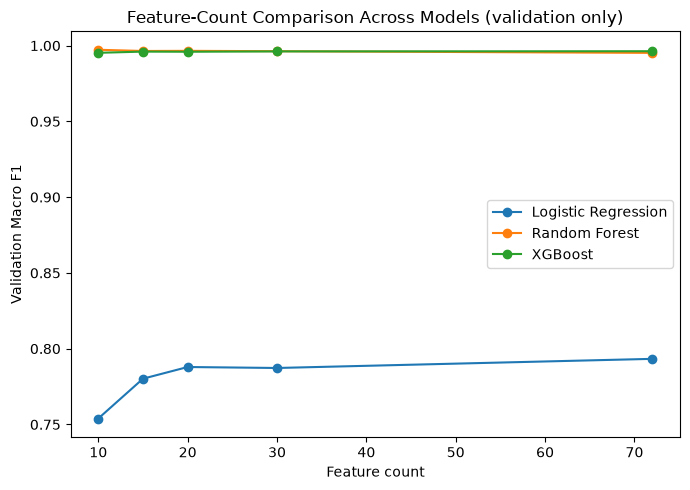

In [2]:
def build_feature_count_comparison():
    frames = []
    for fname in ["logistic_regression_metrics.csv", "random_forest_metrics.csv", "xgboost_metrics.csv"]:
        path = METRICS_DIR / fname
        if path.exists():
            frames.append(pd.read_csv(path))
        else:
            print(f"[skip] {fname} not found.")
    combined = pd.concat(frames, ignore_index=True)
    cols = ["Model", "Feature_Count", "Feature_Set", "Accuracy", "Macro_Precision", "Macro_Recall",
            "Macro_F1", "ROC_AUC", "PR_AUC", "Training_Time", "Inference_Time"]
    return combined[[c for c in cols if c in combined.columns]]


feature_count_comparison = build_feature_count_comparison()
feature_count_comparison.to_csv(METRICS_DIR / "feature_count_comparison.csv", index=False)
print("Saved: metrics/feature_count_comparison.csv")
print(feature_count_comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
for model, g in feature_count_comparison.groupby("Model"):
    g = g.sort_values("Feature_Count")
    ax.plot(g["Feature_Count"], g["Macro_F1"], marker="o", label=model)
ax.set_xlabel("Feature count"); ax.set_ylabel("Validation Macro F1")
ax.set_title("Feature-Count Comparison Across Models (validation only)")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "feature_count_comparison.png", bbox_inches="tight")
print("Saved: figures/feature_count_comparison.png")
plt.show()

### Observation
This chart is purely descriptive of *development-time* decisions already
made in notebooks 06/08/09 — it is not used to pick a winner here, since
each model notebook already froze its own best configuration independently.

## 2. Load Frozen Models and the Final Test Sets

In [3]:
def load_frozen_models():
    models = {}
    for name, fname, scaled in [
        ("Logistic Regression", "logistic_regression.joblib", True),
        ("Random Forest", "random_forest.joblib", False),
        ("XGBoost", "xgboost.joblib", False),
    ]:
        path = MODELS_DIR / fname
        if path.exists():
            bundle = joblib.load(path)
            models[name] = {"model": bundle["model"], "features": bundle["features"],
                             "scaled": scaled, "path": path}
    return models


def load_final_test_sets():
    X_test_processed = pd.read_csv(PROCESSED_DIR / "X_test_processed.csv")
    X_test_tree = pd.read_csv(PROCESSED_DIR / "X_test_tree.csv")
    y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv")["Label"]
    return X_test_processed, X_test_tree, y_test


def load_selected_feature_sets():
    from pathlib import Path as _P
    d = _scripts_dir.parent / "feature_selection"
    return {p.stem: p.read_text().splitlines() for p in d.glob("*.txt")}


frozen_models = load_frozen_models()
X_test_processed, X_test_tree, y_test = load_final_test_sets()
print(f"Loaded {len(frozen_models)} frozen models: {list(frozen_models.keys())}")
print(f"Final test set: {X_test_processed.shape[0]:,} rows (touched for the first time now)")

Loaded 3 frozen models: ['Logistic Regression', 'Random Forest', 'XGBoost']
Final test set: 92,340 rows (touched for the first time now)


## 3. Evaluate Every Frozen Model Once (No Tuning)

In [4]:
def evaluate_final_model(bundle, X_test_processed, X_test_tree, y_test):
    X_test = (X_test_processed if bundle["scaled"] else X_test_tree)[bundle["features"]]
    pred, proba, pred_t = predict_full(bundle["model"], X_test)
    metrics = eval_binary(y_test, pred, proba)
    return metrics, pred, proba, pred_t


def calculate_model_size(path):
    return model_size_mb(path)


final_rows = []
final_predictions_by_model = {}
for name, bundle in frozen_models.items():
    t0 = time.perf_counter()
    metrics, pred, proba, pred_t = evaluate_final_model(bundle, X_test_processed, X_test_tree, y_test)
    size_mb = calculate_model_size(bundle["path"])
    final_rows.append({"Model": name, "Feature_Count": len(bundle["features"]), **metrics,
                        "Training_Time": np.nan, "Inference_Time": pred_t, "Model_Size_MB": size_mb})
    final_predictions_by_model[name] = (pred, proba)
    print(f"{name}: Macro_F1={metrics['Macro_F1']:.4f}  ROC_AUC={metrics['ROC_AUC']:.4f}  "
          f"size={size_mb} MB")

final_model_comparison = pd.DataFrame(final_rows)
print("\n=== FINAL TEST-SET COMPARISON (touched exactly once, no tuning) ===")
print(final_model_comparison.to_string(index=False))

Logistic Regression: Macro_F1=0.7974  ROC_AUC=0.9747  size=0.004 MB


Random Forest: Macro_F1=0.9978  ROC_AUC=0.9996  size=16.158 MB


XGBoost: Macro_F1=0.9960  ROC_AUC=0.9999  size=0.921 MB

=== FINAL TEST-SET COMPARISON (touched exactly once, no tuning) ===
              Model  Feature_Count  Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Weighted_F1  Balanced_Accuracy  ROC_AUC   PR_AUC  Normal_Precision  Normal_Recall  Normal_F1  Anomaly_Precision  Anomaly_Recall  Anomaly_F1  Training_Time  Inference_Time  Model_Size_MB
Logistic Regression             72  0.914143         0.742802      0.920018  0.797375     0.925474           0.920018 0.974721 0.997377          0.492838       0.927073   0.643557           0.992765        0.912964    0.951194            NaN        0.033434          0.004
      Random Forest             10  0.999329         0.999278      0.996338  0.997803     0.999328           0.996338 0.999597 0.999927          0.999218       0.992746   0.995971           0.999339        0.999929    0.999634            NaN        0.132520         16.158
            XGBoost             72  0.998765         0.9

## 4. Build the Final Comparison Table and Plot

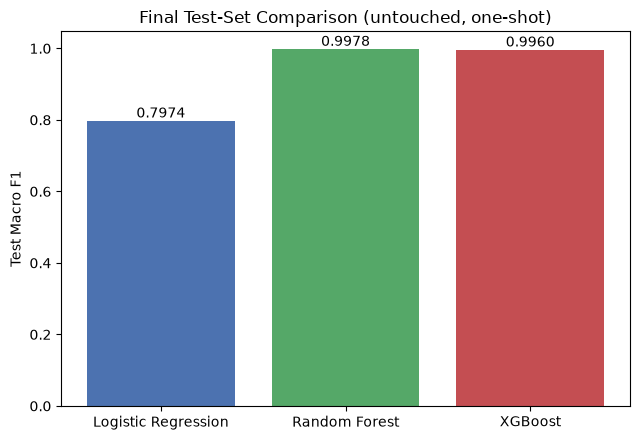

Saved: figures/final_model_comparison.png

>>> BEST MODEL ON THE FINAL TEST SET: Random Forest


In [5]:
def build_final_comparison(df):
    cols = ["Model", "Feature_Count", "Accuracy", "Macro_Precision", "Macro_Recall", "Macro_F1",
            "ROC_AUC", "PR_AUC", "Training_Time", "Inference_Time", "Model_Size_MB"]
    return df[cols]


def plot_final_comparison(df):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.bar(df["Model"], df["Macro_F1"], color=["#4C72B0", "#55A868", "#C44E52"][:len(df)])
    for i, v in enumerate(df["Macro_F1"]):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
    ax.set_ylabel("Test Macro F1"); ax.set_title("Final Test-Set Comparison (untouched, one-shot)")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "final_model_comparison.png", bbox_inches="tight")
    plt.show()


final_comparison_table = build_final_comparison(final_model_comparison)
plot_final_comparison(final_comparison_table)
print("Saved: figures/final_model_comparison.png")

winner_name = final_comparison_table.loc[final_comparison_table["Macro_F1"].idxmax(), "Model"]
print(f"\n>>> BEST MODEL ON THE FINAL TEST SET: {winner_name}")

### Observation
The winner here is determined purely by the untouched test-set Macro-F1 —
it was never used to pick a feature count, hyperparameters, or which model
to freeze; those decisions were all made on validation data in notebooks
06/08/09.

## 5. Save Final Metrics

In [6]:
def save_final_metrics(comparison_df, winner_name):
    comparison_df.to_csv(METRICS_DIR / "final_model_comparison.csv", index=False)
    print("Saved: metrics/final_model_comparison.csv")

    winner_row = comparison_df[comparison_df["Model"] == winner_name].iloc[0].to_dict()
    winner_row = {k: (float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v)
                  for k, v in winner_row.items()}
    winner_row["winner"] = winner_name
    with open(METRICS_DIR / "final_test_metrics.json", "w") as f:
        json.dump(winner_row, f, indent=2, default=str)
    print("Saved: metrics/final_test_metrics.json")
    return winner_row


final_test_metrics = save_final_metrics(final_comparison_table, winner_name)

Saved: metrics/final_model_comparison.csv
Saved: metrics/final_test_metrics.json


## 6. Generate Final Predictions (Winning Model, Final Test Set)

In [7]:
def generate_final_predictions(winner_name, X_test_processed, X_test_tree, y_test, frozen_models):
    bundle = frozen_models[winner_name]
    pred, proba = final_predictions_by_model[winner_name]
    inv_map = {0: "Normal", 1: "Anomaly"}
    return pd.DataFrame({
        "sample_index": y_test.index,
        "actual_label": y_test.map(inv_map).values,
        "predicted_label": [inv_map[p] for p in pred],
        "predicted_probability": proba,
    })


final_predictions = generate_final_predictions(winner_name, X_test_processed, X_test_tree, y_test, frozen_models)
final_predictions.to_csv(PREDICTIONS_DIR / "final_predictions.csv", index=False)
print(f"Saved: predictions/final_predictions.csv ({len(final_predictions):,} rows)")
print(final_predictions.head(10).to_string(index=False))

Saved: predictions/final_predictions.csv (92,340 rows)
 sample_index actual_label predicted_label  predicted_probability
            0      Anomaly         Anomaly                    1.0
            1      Anomaly         Anomaly                    1.0
            2      Anomaly         Anomaly                    1.0
            3      Anomaly         Anomaly                    1.0
            4      Anomaly         Anomaly                    1.0
            5      Anomaly         Anomaly                    1.0
            6       Normal          Normal                    0.0
            7      Anomaly         Anomaly                    1.0
            8      Anomaly         Anomaly                    1.0
            9      Anomaly         Anomaly                    1.0


### Observation
`Src_IP`/`Dst_IP` are intentionally not exported here — predictions are
reported by `sample_index` only, consistent with the leakage/identifier
exclusion rules followed throughout this project.

## Notebook Summary

In [8]:
from IPython.display import display, Markdown

summary_md = f"""
- Consolidated LR/RF/XGBoost's own validation feature-count experiments into
  `metrics/feature_count_comparison.csv` and a comparison figure.
- Loaded all {len(frozen_models)} frozen models (fit on training data only,
  tuned on validation only in notebooks 06/08/09) and evaluated each **once**
  on the untouched final test set ({len(y_test):,} rows).
- **Winner: {winner_name}** — test Macro-F1={final_test_metrics['Macro_F1']:.4f},
  ROC-AUC={final_test_metrics['ROC_AUC']:.4f}, model size={final_test_metrics['Model_Size_MB']} MB.
- Saved `metrics/final_model_comparison.csv`, `metrics/final_test_metrics.json`,
  and `predictions/final_predictions.csv`.

This is the last notebook in the pipeline. Final report generation
(`scripts/generate_report.py`) reads these saved files — never remembered
values — to build `report/Final_Project_Report.docx` and `.pdf`.
"""
display(Markdown(summary_md))


- Consolidated LR/RF/XGBoost's own validation feature-count experiments into
  `metrics/feature_count_comparison.csv` and a comparison figure.
- Loaded all 3 frozen models (fit on training data only,
  tuned on validation only in notebooks 06/08/09) and evaluated each **once**
  on the untouched final test set (92,340 rows).
- **Winner: Random Forest** — test Macro-F1=0.9978,
  ROC-AUC=0.9996, model size=16.158 MB.
- Saved `metrics/final_model_comparison.csv`, `metrics/final_test_metrics.json`,
  and `predictions/final_predictions.csv`.

This is the last notebook in the pipeline. Final report generation
(`scripts/generate_report.py`) reads these saved files — never remembered
values — to build `report/Final_Project_Report.docx` and `.pdf`.
